# Dynamic Pupil Size Model Pipeline

### Modified from Cai et al.
A - 
B - 
C - 
D -

## A - Imports & Dependencies

In [93]:
import cv2
import logging
import math
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time


from classes.preprocessing import preprocessing
from classes.video_handler import visual_field_mask
#from classes.video_processing import video_processing
#from classes.image_processing import image_processing
from classes.event_extraction import event_extraction
from classes.pupil_prediction import pupil_prediction
from classes.interactive_plot import interactive_plot

In [ ]:
''' NOT USED, DELETE LATER '''
import matplotlib.lines as mlines
from matplotlib import pyplot as plt
from matplotlib.widgets import Slider, Button,TextBox,CheckButtons
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

import os


from PIL import Image, ImageTk

import sys
from scipy.optimize import minimize
from scipy.optimize import basinhopping
from scipy.interpolate import PchipInterpolator


import threading
from threading import *


In [72]:
import classes.video_handler as video_handler

importlib.reload(video_handler)
from classes.video_handler import VisualFieldMask

## B - Data Loading routines

In [2]:
def get_dir(base_dir):
    data_dir = base_dir / "Example"
    input_dir = data_dir / "Input"
    output_dir = data_dir / "Output"
    movie_dir = input_dir / "Movies"
    eyetracking_dir = input_dir / "Eyetracking"
    
    return(output_dir, movie_dir, eyetracking_dir, data_dir)


def get_movie_names(movie_dir):
    return [file.stem for file in movie_dir.iterdir()]


def get_subject_paths(eyetracking_dir, gaze_centered):
    if not gaze_centered:
        return ["sc"]
    if not eyetracking_dir.exists():
        print("No eyetracking folder found.")
        return ["NoEyetrackingData"]
        
    return [subject for subject in eyetracking_dir.iterdir() if subject.is_dir()]


def make_output_dir(output_dir, sub_dir):
    output_path = output_dir / sub_dir
    output_path.mkdir(parents=True,exist_ok=True)
    
    return output_path

def make_model_dict(picklename):
    if picklename.exists():
        with open(picklename,"rb") as handle:
            model_dict = pickle.load(handle)
    else:
        model_dict = {}
        
    return model_dict

## C - Mask Creation
Idea: Create a mask once, and use copies for each subject

In [73]:
def check_video_screen_relation(video_real_height, video_real_width, eyetracking_height, eyetracking_width):
    if video_real_height == eyetracking_height and video_real_width == eyetracking_width:
        return True, True

    elif video_real_height == eyetracking_height or video_real_width == eyetracking_width:
        return False, True
    else:
        return False, False

def calculate_deg_vf(video_real_width, eyetracking_width, screen_width, eye_to_screen,deg_vf_param):
    video_width_cm = video_real_width / (eyetracking_width / screen_width)
    video_width_deg = math.degrees(math.atan(video_width_cm / 2 / eye_to_screen)) * 2

    return video_width_deg * deg_vf_param

def calculate_px(degVF,eye_to_screen,eyetracking_width,screen_width):
    circle_diameter_cm = np.tan((degVF/2) * np.pi / 180) * eye_to_screen *2
    eyetracker_px_cm = eyetracking_width / screen_width
    circle_diameter_px = int(round(eyetracker_px_cm * circle_diameter_cm))
    #print(circle_diameter_cm, eyetracker_px_cm, circle_diameter_px)
    return circle_diameter_px / 2


def create_stimulus_matrix(n_weight:int, circle_radius_px:float) -> np.ndarray:
    """
    Create the circular visual-field region map.

    Each pixel receives a regional ID:
        0 = outside the weighted regions
        1, 2, ... = visual-field region

    Args:
        n_weight:
            Number of visual-field regions. Supported values:
            2, 20, 24 or 44.

        circle_radius_px:
            Radius of the visual-field mask in pixels.

    Returns:
        A 2D NumPy array containing the regional IDs.
    """
    if circle_radius_px <= 0:
        raise ValueError("circle_radius_px must be greater than zero.")
    
    if n_weight == 24:
        annulus_radii_px = np.around(
            np.array([109, 218, 336, 447]) 
            * (circle_radius_px/447)
        ).astype(int)
        wedges_per_annulus = [4, 6, 6, 8]
        radial_boundaries_px = np.hstack((0, annulus_radii_px)) # add the center as the inner boundary

    elif n_weight in (2,44):
        annulus_radii_px = np.around(
            np.array([70, 149, 218, 336, 447]) 
            * (circle_radius_px/447)
        ).astype(int)
        wedges_per_annulus = [4, 8, 8, 12, 12]
        radial_boundaries_px = np.hstack((0, annulus_radii_px))

    elif n_weight == 20:
        annulus_radii_px = np.around(
            np.array([7.42, 11.810400000000001, 16.727648000000002, 22.23496576]) 
            * (circle_radius_px/22.23496576)
        ).astype(int)
        wedges_per_annulus = [6,6,8]
        radial_boundaries_px = annulus_radii_px # the center part is not counted as wedges (gaze included)
    else:
        raise ValueError(
            f"Unsupported n_weight = {n_weight}. "
            "Expected 2, 20, 24, or 44"
        )
        
    max_radius_px = int(np.max(annulus_radii_px))
    
    coordinates = np.arange(-max_radius_px, max_radius_px + 1)
    x_coords, y_coords = np.meshgrid(coordinates, coordinates)   # x,y coordinates of pixels
    
    radial_distance = np.hypot(x_coords, y_coords)               # polar coordinates of pixels
    angle = np.arctan2(y_coords, x_coords)

    # 2d map holding region labels for pixels
    region_label_map = np.zeros(
        shape=(2 * max_radius_px + 1, 2 * max_radius_px + 1),
        dtype=np.int16,
    )

    region_id = 0

    # iterate through the circles ( <-( <-( )-> )-> )
    for annulus_idx, n_wedges in enumerate(wedges_per_annulus):

        # Define and apply radial boundaries
        inner_radius = radial_boundaries_px[annulus_idx]
        outer_radius = radial_boundaries_px[annulus_idx + 1]

        pixels_in_annulus = (
            (radial_distance > inner_radius)
            & (radial_distance <= outer_radius)
        )

        wedge_boundaries = np.linspace(-np.pi, np.pi, n_wedges + 1)

        # iterate trough regions in circle
        for wedge_idx in range(n_wedges):
            region_id += 1

            lower_angle = wedge_boundaries[wedge_idx]
            upper_angle = wedge_boundaries[wedge_idx + 1]

            pixels_in_wedge = (
                (angle > lower_angle)
                & (angle <= upper_angle)
            )

            region_label_map[
                pixels_in_annulus & pixels_in_wedge
            ] = region_id

    if n_weight == 2:
        region_label_map = collapse_to_left_right_regions(region_label_map)

    return region_label_map
    


def collaps_to_left_right_regions(region_label_map: np.ndarray)->np.ndarray:
    """
    Collapse the 44-region map into:
        0 = outside the circular mask
        1 = left visual field
        2 = right visual field
    """
    left_region_ids = np.array([
        1, 5, 6, 13, 14, 21, 22, 23, 33, 34, 35,
        4, 11, 12, 19, 20, 30, 31, 32, 42, 43, 44,
    ])

    right_region_ids = np.array([
        2, 7, 8, 15, 16, 24, 25, 26, 36, 37, 38,
        3, 9, 10, 17, 18, 27, 28, 29, 39, 40, 41,
    ])

    collapsed_map = np.zeros_like(region_label_map)

    collapsed_map[np.isin(region_label_map, left_region_ids)] = 1
    collapsed_map[np.isin(region_label_map, right_region_ids)] = 2

    return collapsed_map
    
def create_visual_field_mask(
    map_type: str,
    n_weight: int,
    eyetracking_width_px: int,
    eyetracking_height_px: int,
    circle_radius_px: float,
) -> VisualFieldMask:
    """
    Create a reusable circular or square visual-field mask. This should normally be 
    called once before looping over subjects.

    Args:
        map_type : Either "circular" or "square".
        n_weight : Number of regional weights used by the circular mask.
        eyetracking_width_px : Width of the eye-tracking coordinate system in pixels.
        eyetracking_height_px : Height of the eye-tracking coordinate system in pixels.
        circle_radius_px : radius of Visual Field in pixels. 
    Returns:
        A VisualFieldMask object.
    """
    

    if map_type == "circular":
        region_label_map = create_stimulus_matrix(n_weight,circle_radius_px)

        region_ids = np.arange(1,int(region_label_map.max()) + 1)

        # Vectorized replacement for the old repeated vstack loop.
        region_masks_flat = (
            region_label_map.ravel()[None, :]
            == region_ids[:, None]
        ).astype(np.uint8)

        pixels_per_region = region_masks_flat.sum(axis=1)

        final_height_px, final_width_px = region_label_map.shape

        scale_factor = (
            final_width_px
            / min(eyetracking_height_px, eyetracking_width_px)
        )

        return VisualFieldMask(
            map_type=map_type,
            final_width_px=final_width_px,
            final_height_px=final_height_px,
            scale_factor=scale_factor,
            region_label_map=region_label_map,
            region_masks_flat=region_masks_flat,
            pixels_per_region=pixels_per_region,
        )

    square_width_px = circle_radius_px * 2

    square_height_px = int(
        square_width_px
        / (eyetracking_width_px / eyetracking_height_px)
    )

    scale_factor = (
        square_width_px
        / min(eyetracking_height_px, eyetracking_width_px)
    )

    return VisualFieldMask(
        map_type=map_type,
        final_width_px=square_width_px,
        final_height_px=square_height_px,
        scale_factor=scale_factor,
        square_width_px=square_width_px,
        square_height_px=square_height_px,
    )

## D - Visual Event Extraction
    


To model pupil size dynamics, visual events (i.e. luminance changes) are extracted from the stimulus material first (movie frames).

In [52]:
def extract_video_metadata(video_path):
    """
    Creates a video handler object, opens the video file 
    and extracts metadata from the video.
    
    Args:
        movie_path: path to the movie file
    Returns:
        vidInfo: Metadata stored as dictionary
    """
    cap = cv2.VideoCapture(str(video_path))
    video_info = {}
    video_info["path"] = video_path
    video_info["fps"] = int(cap.get(cv2.CAP_PROP_FPS))
    video_info["nFrames"] = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_info["codecnum"] = cap.get(cv2.CAP_PROP_FOURCC)
    video_info["codec"] = (
            "".join(
                [chr((int(cap.get(cv2.CAP_PROP_FOURCC)) >> 8 * i) & 0xFF) for i in range(4)]
            ),
    )
    video_info["duration"] = video_info["nFrames"] / video_info["fps"]
    video_info["height"] = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    video_info["width"] = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_info["ratio"] = video_info["height"] / video_info["width"]
    video_info["overall_lum"] = None
    
    return video_info



def load_eyetracking_csv(csv_path,expected_sampling_rate):
    """
    Loads eyetracking data and ensures timestamps are in seconds rather than milliseconds

    Args:
        csv_path: path to eyetracking file
        expected_sampling_rate: expected sampling rate of the eyetracker
    """
    df = pd.read_csv(csv_path, header=None,index_col=None,sep=",")
    
    df.iloc[:,0] = df.iloc[:,0]-df.iloc[0,0]     # column 0 = timestamps
    
    duration = df.iloc[-1,0]
    n_samples = df.shape[0]

    estimated_sampling_rate = round(n_samples/duration)
    #print(estimated_sampling_rate)

    if expected_sampling_rate != estimated_sampling_rate:
        df.iloc[:, 0] = df.iloc[:, 0] / 1000
        duration = df.iloc[-1, 0]

    return df, duration, n_samples


def make_pickle_name(movie_name, subject_name, map_type, color_space, n_weight):
    return (
        f"{map_type}_{movie_name}_{subject_name}_VF_"
        f"{color_space}_nWeight_{n_weight}.pickle"
    )

## E - Executing pipeline

### Information entered by the user

In [27]:
root_path = "C:/Users/stock/Documents/Master BME/Masterarbeit/7_OpenDPSM/v4"
max_luminance = 212             # in [cd/m2]

# Resolution of Eyetracking data (Screen)
eyetracking_height = 1080       # in [pix]
eyetracking_width = 1920        # in [pix]
eyetracking_sampling_rate = 300 # in [Hz]

video_real_height = 1080        # in [pix]
video_real_width = 1920         # in [pix]

screen_width = 59.5             # in [cm]
eye_to_screen = 65              # in [cm]

# Size of the regional weight map relative to the size of the video
degVF_param = 1                 # =1 -> same size, for large video make it smaller!

screen_bg_color = [0,0,0]       # Background color if video and screen are not same size


gaze_centered = True            # if False, map_type must be "square
map_type = "circular"           # altern. "square"

# square: (2,6,48) -> left/right, 6 regions, all 48 regions separately, // circluar: (2,44)
n_weight = 44

# model each movie separately or all movies together for each subject
modeling_type = "separate"     # all or separate

pupil_zscore = False           # Modeling for abs. pupil size not just changes
saveParams = True              # Save Model evaluation and parameters
saveData = True                # Save Data used for modeling
use_app = False

event_extracted = False
overall_lum_extracted = False

### Data Loading

In [28]:
base_dir = Path(root_path)

output_dir,movie_dir,eyetracking_dir, data_dir = get_dir(base_dir)
output_path_v = make_output_dir(output_dir, "Visual events")
movie_names = get_movie_names(movie_dir)
subjects = get_subject_paths(eyetracking_dir, gaze_centered)

In [29]:
folder_modeling_result = "Modeling result"
folder_csv_result = "csv results"

In [41]:
exec(open(base_dir / "settings.py").read(), globals())

### Mask creation
create mask once, and the give out copies to the subjects. 

In [88]:
video_screen_same_ratio, video_stretched = check_video_screen_relation(
            video_real_height,
            video_real_width,
            eyetracking_height,
            eyetracking_width
)

degVF = calculate_deg_vf(
            video_real_width, 
            eyetracking_width, 
            screen_width, 
            eye_to_screen,
            degVF_param
)

circle_radius_px = calculate_px(
    degVF,
    eye_to_screen,
    eyetracking_width,
    screen_width
)
VisualFieldMask = create_visual_field_mask(
    map_type,
    n_weight,
    eyetracking_width,
    eyetracking_height,
    circle_radius_px
 )

[[0.7316957  0.33414693 0.04143076 0.486004   0.8387147  0.82346979
  0.05490112 0.99437583 0.64551325 0.92302848 0.6256871  0.42622535]
 [0.35230546 0.46484858 0.71985582 0.22575442 0.67620787 0.72538595
  0.54682017 0.39648354 0.30808172 0.21161409 0.60922331 0.83828878]
 [0.44779917 0.6209375  0.18908251 0.6072062  0.62174536 0.69842649
  0.96080106 0.08742975 0.2964749  0.13305877 0.51342021 0.67478944]
 [0.77564517 0.19118043 0.13439759 0.84541671 0.67078056 0.69193444
  0.19027592 0.33917745 0.40069576 0.9497264  0.33110149 0.79775659]
 [0.98611838 0.33936452 0.96673211 0.50324273 0.34250676 0.74267167
  0.59190145 0.79981872 0.98941039 0.84018621 0.90604801 0.00526543]
 [0.46443382 0.78361613 0.35456487 0.55284982 0.95012279 0.6544619
  0.28358212 0.07778041 0.51908634 0.28196096 0.4490177  0.90759181]
 [0.44115767 0.93655838 0.0348114  0.09868972 0.03683025 0.56368347
  0.91837172 0.88895219 0.3232195  0.4153014  0.91565126 0.1671458 ]
 [0.64662872 0.99586189 0.5520956  0.23298

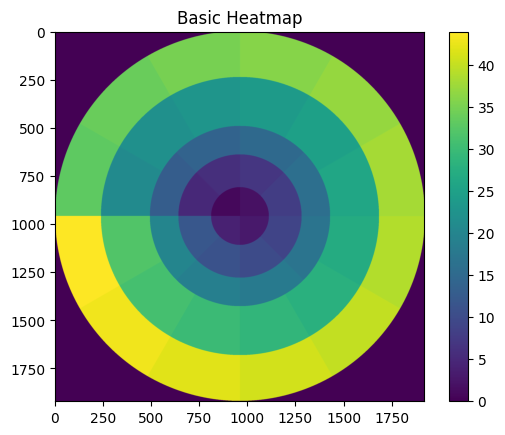

In [92]:
import numpy as np
import matplotlib.pyplot as plt


data = VisualFieldMask.region_label_map
# Create a heatmap
plt.imshow(data)
plt.title("Basic Heatmap")
plt.colorbar()
plt.show()

### Precompute Movie Information

In [54]:
video_metadata = {}
for v in movie_dir.glob("*.mp4"):
    video_metadata[v.stem] = extract_video_metadata(v)

    
    
# maybe extract events and overall lumiance here, provided, this has not been done yet. 

In [53]:
video_screen_same_ratio, video_stretched = check_video_screen_relation(
            video_real_height,
            video_real_width,
            eyetracking_height,
            eyetracking_width
)

degVF = calculate_deg_vf(
            video_real_width, 
            eyetracking_width, 
            screen_width, 
            eye_to_screen,
            degVF_param
)

59.5 32.26890756302521 1920


### classes.event_extraction

This class of functions serves to extract the timing and strength of visual events (luminance and contrast changes) of an input video file. <br>
These features are used for estimating pupil trace using convolution wiht response functions.

In [ ]:
#iteratively extract events for all the subjects
for subject in subjects:
    subject_name = subject.name

    
    # Compare Subject eyetracking data with available movies
    csv_files = list(subject.glob("*.csv"))
    missing_movies = [csv.name for csv in csv_files if csv.stem not in movie_names]
 
    if missing_movies:
        print(f"Warning: {len(missing_movies)} movies not found")
    
    for csv_path in csv_files:
        
        movie_name = csv_path.stem
        video_info = video_metadata.get(movie_name)
    
        if video_info is None:
            print(f"Movie not found: {movie_name}")
            continue
        
        # Extracting eyetracking data
        df_eyetracking = None
        eyetracking_duration = None

        if gaze_centered:
            df_eyetracking, eyetracking_duration, eyetracking_n_samples = load_eyetracking_csv(
                csv_path,
                eyetracking_sampling_rate
            )

        pickle_name = make_pickle_name(
            movie_name,
            subject_name,
            map_type,
            colorSpace,
            n_weight
        )
        
        pickle_path = output_path_v / pickle_name
        
        if (pickle_path).exists():
            print(f"Subject {subject_name}, movie {movie_name} already extracted")
            event_extracted = True
            
        
        overall_lum_extracted = (video_info['overall_lum'] is not None)

        if not event_extracted or not overall_lum_extracted:
            
            print(f"==== Extracting subject {subject_name}, movie {movie_name} ====")

            ee = event_extraction()
            
            ee.gazecentered = gaze_centered
            ee.maxlum = max_luminance
            ee.useApp = use_app
            ee.mapType = map_type
            ee.degVF = degVF
            ee.eye_to_screen = eye_to_screen
            ee.screen_width = screen_width
            ee.nWeight = n_weight
        
            # parameters from settings
            ee.setNBufFrames(nFramesSeqImageDiff + 1)
            ee.imCompFeatures = True
            ee.showVideoFrames = showVideoFrames
            ee.imColSpaceConv = colorSpace
            ee.nVertMatPartsPerLevel = nVertMatPartsPerLevel
            ee.aspectRatio = aspectRatio
            ee.imageSector = imageSector
            ee.nFramesSeqImageDiff = nFramesSeqImageDiff
            ee.selectFeatures = featuresOfInterest
            ee.scrGamFac = scrGamFac

            ee.video_duration = video_info["duration"]
            ee.video_fps = video_info["fps"]
            ee.vidInfo = video_info
            ee.stretchToMatch = stretchToMatch

            ee.subject = subject_name
            ee.movieNum = movie_name
            ee.picklename = pickle_path
            ee.filename_movie = video_info["path"]
        
        

            if gaze_centered:
                ee.eyetracking_duration = eyetracking_duration
                ee.eyetracking_height = eyetracking_height
                ee.eyetracking_width = eyetracking_width
                ee.eyetracking_samplingrate = eyetracking_sampling_rate

                ee.videoRealHeight = video_real_height
                ee.videoRealWidth = video_real_width

                ee.screenBgColorR = screen_bg_color[0]
                ee.screenBgColorG = screen_bg_color[1]
                ee.screenBgColorB = screen_bg_color[2]

                ee.videoScreenSameRatio = video_screen_same_ratio
                ee.videoStretched = video_stretched

                # Extract columns from dataframe
                timestamps = np.array(df_eyetracking.iloc[:, 0])
                gaze_x = np.array(df_eyetracking.iloc[:, 1])
                gaze_y = np.array(df_eyetracking.iloc[:, 2])
                pupil = np.array(df_eyetracking.iloc[:, 3])

                # Adjust the length of the eyetracking data to the length of the videos.     Later maype use timestamps!!
                ee.sampledTimeStamps_featureExtraction = ee.prepare_sampleData(timestamps,video_info['nFrames'])
                ee.sampledgazexData_featureExtraction = ee.prepare_sampleData(gaze_x,video_info['nFrames'])
                ee.sampledgazeyData_featureExtraction = ee.prepare_sampleData(gaze_y,video_info['nFrames'])
                ee.sampledpupilData_featureExtraction = ee.prepare_sampleData(pupil,video_info['nFrames'])

            # Event extraction function:
            # The extracted features will be saved in folder "Visual events"
            if not event_extracted:
                ee.run()

            if not overall_lum_extracted:
                video_metadata[movie]['overall_lum'] = ee.overall_lum_extraction()

print("====Finish preprocessing and visual event extraction for all subjects and movies.====")

In [ ]:
""" Save overall luminances """
df_overall_lum = pd.DataFrame(
    [
        {
            "movie": movie,
            "overall_lum": info["overall_lum"]
        }
        for movie, info in video_metadata.items()
    ]
)

List of optimizations:
- dont create preprocessing class, just load videos straigth using load_video_info, and only load videos once and not for each subject individually.
- precomputing movie info once
- right now we loop through each movie for every subject, do movie analysis seperatly from subjects.
- overall luminance is used for pupil baseline, holds the mean luminance of the film. (We could use Watson and Yellot for this instead) Use adjusting parameter just like Zandi and Khanh 0.41mm
- 